# WildScan – Plants Phylum CNN
Classifies plant images into taxonomic phyla (e.g. Tracheophyta, Bryophyta, Marchantiophyta).
Second stage in the WildScan plant pipeline: CNN1 → **Phylum** → Class → Species

## 1. Setup

In [ ]:
import os, shutil, time, random
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFile
from io import BytesIO

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import classification_report, confusion_matrix

ImageFile.LOAD_TRUNCATED_IMAGES = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 2. Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 3. Download Plant Images by Phylum

In [ ]:
PHYLUM_DIR = './data/plants_phylum'
TARGET = 500

# Major plant phyla with their iNaturalist taxon IDs
PHYLUM_TAXONS = {
    'Tracheophyta':    211194,  # vascular plants (largest group)
    'Bryophyta':       311250,  # mosses
    'Marchantiophyta': 311249,  # liverworts
}

taxon_cache = {}

def get_phylum(taxon_id):
    if taxon_id in taxon_cache:
        return taxon_cache[taxon_id]
    for attempt in range(3):
        try:
            r = requests.get(f'https://api.inaturalist.org/v1/taxa/{taxon_id}', timeout=10)
            if r.status_code == 429:
                time.sleep(60)
                continue
            if r.status_code != 200:
                return None
            ancestors = r.json()['results'][0].get('ancestors', [])
            phylum = next((a['name'] for a in ancestors if a.get('rank') == 'phylum'), None)
            taxon_cache[taxon_id] = phylum
            time.sleep(0.3)
            return phylum
        except Exception:
            time.sleep(2)
    return None

for phylum_name, taxon_id in PHYLUM_TAXONS.items():
    folder = os.path.join(PHYLUM_DIR, phylum_name)
    os.makedirs(folder, exist_ok=True)
    current = len(os.listdir(folder))
    needed = TARGET - current
    if needed <= 0:
        print(f'{phylum_name}: already has {current} images, skipping')
        continue
    print(f'{phylum_name}: fetching {needed} images...')
    fetched, page = 0, 1
    while fetched < needed and page <= 100:
        try:
            response = requests.get(
                'https://api.inaturalist.org/v1/observations',
                params={'taxon_id': taxon_id, 'quality_grade': 'research',
                        'photos': True, 'per_page': 100, 'page': page, 'order_by': 'id'},
                timeout=10
            )
            if response.status_code == 429:
                time.sleep(60)
                continue
            for obs in response.json().get('results', []):
                if fetched >= needed:
                    break
                try:
                    photo_url = obs['photos'][0]['url'].replace('square', 'medium')
                    img_data = requests.get(photo_url, timeout=10).content
                    img = Image.open(BytesIO(img_data)).convert('RGB')
                    count = len(os.listdir(folder))
                    img.save(os.path.join(folder, f'{count:05d}.jpg'))
                    fetched += 1
                except Exception:
                    continue
            page += 1
            time.sleep(1)
        except Exception:
            time.sleep(5)
            page += 1
    print(f'  Done! {phylum_name} now has {len(os.listdir(folder))} images')

print('\nFinal counts:')
for cls in sorted(os.listdir(PHYLUM_DIR)):
    print(f'  {cls}: {len(os.listdir(os.path.join(PHYLUM_DIR, cls)))} images')

Tracheophyta: fetching 500 images...
  Done! Tracheophyta now has 500 images
Bryophyta: fetching 500 images...
  Done! Bryophyta now has 0 images
Marchantiophyta: fetching 500 images...
  Done! Marchantiophyta now has 500 images

Final counts:
  Bryophyta: 0 images
  Marchantiophyta: 500 images
  Tracheophyta: 500 images


In [10]:
import requests, time, os
from PIL import Image
from io import BytesIO

PHYLUM_DIR = './data/plants_phylum'
folder = os.path.join(PHYLUM_DIR, 'Bryophyta')
os.makedirs(folder, exist_ok=True)

# Try taxon ID 311250 for Bryophyta (mosses)
taxon_id = 311249  # corrected
TARGET = 200
fetched, page = 0, 1

while fetched < TARGET and page <= 100:
    try:
        response = requests.get(
            'https://api.inaturalist.org/v1/observations',
            params={'taxon_id': taxon_id, 'quality_grade': 'research',
                    'photos': True, 'per_page': 100, 'page': page, 'order_by': 'id'},
            timeout=10
        )
        for obs in response.json().get('results', []):
            if fetched >= TARGET:
                break
            try:
                photo_url = obs['photos'][0]['url'].replace('square', 'medium')
                img_data = requests.get(photo_url, timeout=10).content
                img = Image.open(BytesIO(img_data)).convert('RGB')
                count = len(os.listdir(folder))
                img.save(os.path.join(folder, f'{count:05d}.jpg'))
                fetched += 1
            except Exception:
                continue
        page += 1
        time.sleep(1)
    except Exception:
        time.sleep(5)
        page += 1

print(f'Bryophyta now has {len(os.listdir(folder))} images')

Bryophyta now has 200 images


## 4. Save Data to Drive

In [11]:
if not os.path.exists('/content/drive/MyDrive/plants_phylum'):
    shutil.copytree(PHYLUM_DIR, '/content/drive/MyDrive/plants_phylum')
    print('Saved to Drive!')
else:
    print('Already exists in Drive, skipping.')

Already exists in Drive, skipping.


## 5. EDA

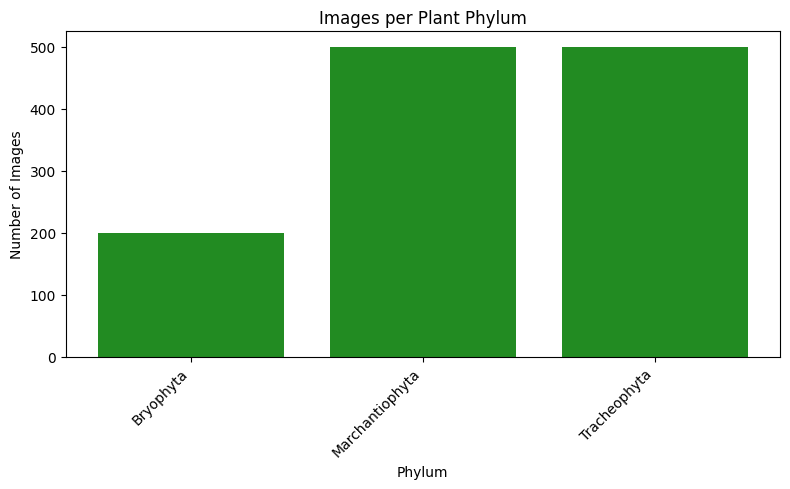

Total: 1200


In [12]:
classes = sorted(os.listdir(PHYLUM_DIR))
class_counts = {cls: len(os.listdir(os.path.join(PHYLUM_DIR, cls))) for cls in classes}

plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='forestgreen')
plt.title('Images per Plant Phylum')
plt.xlabel('Phylum')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('Total:', sum(class_counts.values()))

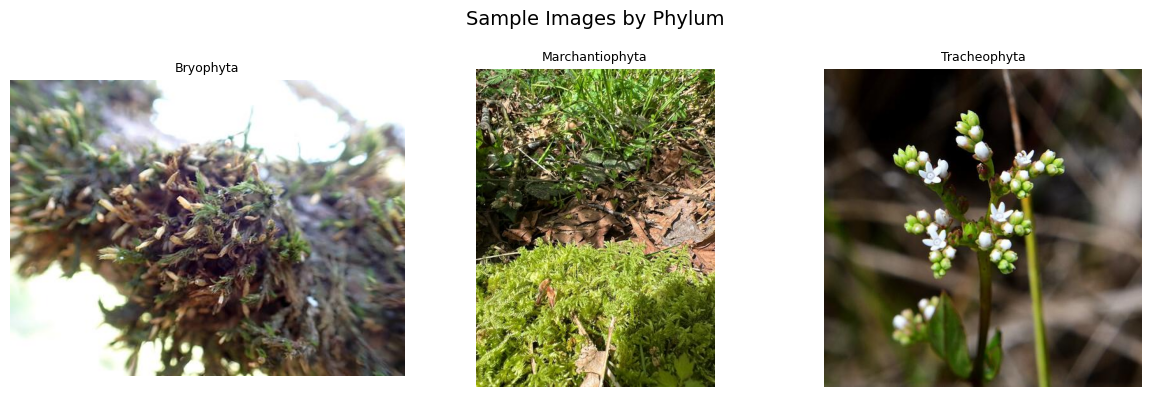

In [13]:
fig, axes = plt.subplots(1, len(classes), figsize=(4 * len(classes), 4))
for ax, cls in zip(axes, classes):
    cls_path = os.path.join(PHYLUM_DIR, cls)
    img = Image.open(os.path.join(cls_path, os.listdir(cls_path)[0])).convert('RGB')
    ax.imshow(img)
    ax.set_title(cls, fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Images by Phylum', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Preprocessing & DataLoaders

In [14]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

full_dataset = ImageFolder(root=PHYLUM_DIR, transform=None)
class_to_idx = full_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}
NUM_CLASSES = len(class_to_idx)
print('Classes:', class_to_idx)
print(f'Total samples: {len(full_dataset)}')

total = len(full_dataset)
train_size = int(0.90 * total)
val_size   = int(0.05 * total)
test_size  = total - train_size - val_size

train_data, val_data, test_data = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)
print(f'Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')

Classes: {'Bryophyta': 0, 'Marchantiophyta': 1, 'Tracheophyta': 2}
Total samples: 1200
Train: 1080 | Val: 60 | Test: 60


In [15]:
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self):
        return len(self.subset)
    def __getitem__(self, idx):
        img, label = self.subset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

BATCH_SIZE = 32
train_loader = DataLoader(TransformSubset(train_data, train_transforms),   batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(TransformSubset(val_data,   val_test_transforms), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(TransformSubset(test_data,  val_test_transforms), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print('DataLoaders ready!')

DataLoaders ready!


## 7. Model – Fine-Tuned ResNet-18

In [16]:
model = models.resnet18(weights='IMAGENET1K_V1')

for param in model.parameters():
    param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3)

print(f'Model ready! Classes: {NUM_CLASSES}')
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 136MB/s]


Model ready! Classes: 3
Trainable params: 11,178,051


## 8. Training

In [17]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


def eval_epoch(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total


NUM_EPOCHS = 20
train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_acc = 0
best_model_path = 'best_plants_phylum_model.pth'

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = eval_epoch(model,  val_loader,   criterion)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(f'Epoch {epoch+1:02d}/{NUM_EPOCHS} | '
          f'Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | '
          f'Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')

print(f'\nBest Val Accuracy: {best_val_acc:.4f}')

Epoch 01/20 | Train Loss: 0.7396 Acc: 0.6611 | Val Loss: 0.4779 Acc: 0.7667
Epoch 02/20 | Train Loss: 0.5205 Acc: 0.7648 | Val Loss: 0.5917 Acc: 0.7333
Epoch 03/20 | Train Loss: 0.4142 Acc: 0.7972 | Val Loss: 0.5856 Acc: 0.6833
Epoch 04/20 | Train Loss: 0.4097 Acc: 0.8037 | Val Loss: 0.5077 Acc: 0.8000
Epoch 05/20 | Train Loss: 0.3782 Acc: 0.8028 | Val Loss: 0.5341 Acc: 0.7833
Epoch 06/20 | Train Loss: 0.3492 Acc: 0.8167 | Val Loss: 0.5214 Acc: 0.7500
Epoch 07/20 | Train Loss: 0.3188 Acc: 0.8333 | Val Loss: 0.5356 Acc: 0.7500
Epoch 08/20 | Train Loss: 0.3155 Acc: 0.8259 | Val Loss: 0.5396 Acc: 0.7333
Epoch 09/20 | Train Loss: 0.3079 Acc: 0.8435 | Val Loss: 0.5378 Acc: 0.7167
Epoch 10/20 | Train Loss: 0.3138 Acc: 0.8269 | Val Loss: 0.5400 Acc: 0.7500
Epoch 11/20 | Train Loss: 0.2969 Acc: 0.8500 | Val Loss: 0.5496 Acc: 0.7167
Epoch 12/20 | Train Loss: 0.3164 Acc: 0.8324 | Val Loss: 0.5442 Acc: 0.7333
Epoch 13/20 | Train Loss: 0.3105 Acc: 0.8296 | Val Loss: 0.5450 Acc: 0.7333
Epoch 14/20 

## 9. Results

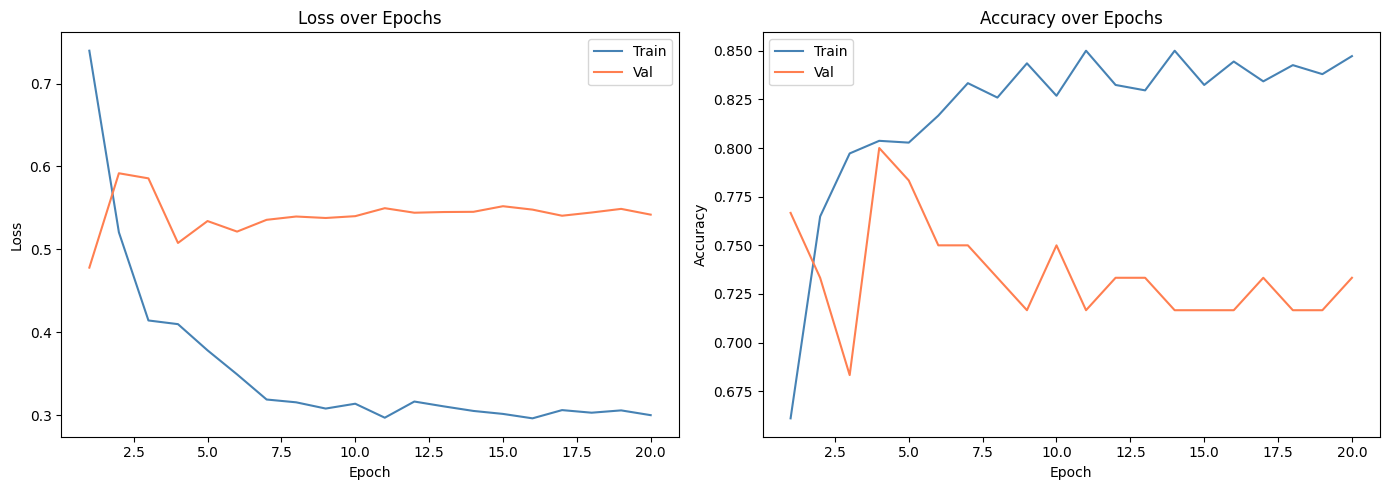

In [18]:
epochs = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, train_losses, label='Train', color='steelblue')
ax1.plot(epochs, val_losses,   label='Val',   color='coral')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, train_accs, label='Train', color='steelblue')
ax2.plot(epochs, val_accs,   label='Val',   color='coral')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.tight_layout()
plt.show()

In [19]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = model(imgs.to(device))
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
class_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

print(f'General Accuracy: {(all_preds == all_labels).mean():.4f} ({(all_preds == all_labels).mean()*100:.2f}%)')
print()

cm = confusion_matrix(all_labels, all_preds)
tp = np.diag(cm)
fp = cm.sum(axis=0) - tp
actual = cm.sum(axis=1)

print(f'{"Class":<25} {"TP":>6} {"FP":>6} {"Actual":>8} {"Precision":>10}')
print('-' * 60)
for i, cls in enumerate(class_names):
    precision = tp[i] / (tp[i] + fp[i]) if (tp[i] + fp[i]) > 0 else 0
    print(f'{cls:<25} {tp[i]:>6} {fp[i]:>6} {actual[i]:>8} {precision:>10.4f}')

General Accuracy: 0.7167 (71.67%)

Class                         TP     FP   Actual  Precision
------------------------------------------------------------
Bryophyta                      0      5       10     0.0000
Marchantiophyta               26     11       32     0.7027
Tracheophyta                  17      1       18     0.9444


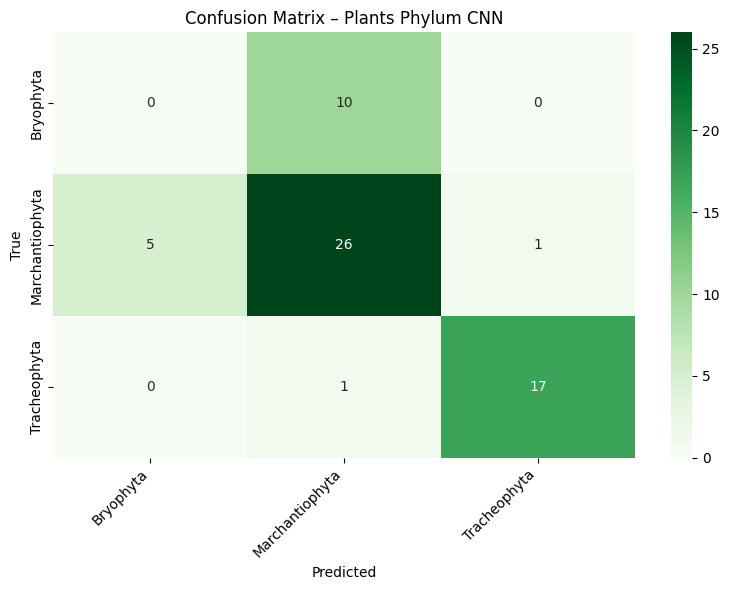

                 precision    recall  f1-score   support

      Bryophyta       0.00      0.00      0.00        10
Marchantiophyta       0.70      0.81      0.75        32
   Tracheophyta       0.94      0.94      0.94        18

       accuracy                           0.72        60
      macro avg       0.55      0.59      0.57        60
   weighted avg       0.66      0.72      0.69        60



In [20]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names,
            yticklabels=class_names, cmap='Greens')
plt.title('Confusion Matrix – Plants Phylum CNN')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

## 10. Save to Drive

In [21]:
shutil.copy(best_model_path, '/content/drive/MyDrive/best_plants_phylum_model.pth')
print('Model saved to Drive!')

Model saved to Drive!
